## 1. Project Setup

In [15]:
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from IPython.display import display

## 2. Data Loading

In [16]:
file_path = 'FMCG.xlsx'
xls = pd.ExcelFile(file_path)

df_sales = pd.read_excel(xls, 'Sales_Transactions')
df_inv = pd.read_excel(xls, 'Inventory_Summary')
df_sku = pd.read_excel(xls, 'SKU_Master')
df_sales.head(5)
df_inv.head()

,SKU_ID,Product_Name,Brand,Sub_Category,Category,Warehouse_Zone,Supplier_ID,Region,Stock_Entry_Date,Expiry_Date,...,Reorder_Point,Lead_Time_Days,Total_Qty_Sold,Total_Revenue_INR,Total_Profit_INR,Avg_Unit_Sell_INR,Avg_Unit_Cost_INR,Return_Count,Aging_Bucket,Inventory_Status
0,FMCG_BEV_0001,Tropicana Juices 500g,Tropicana,Juices,Beverages,Zone-D,SUP_002,North,2022-04-15,2022-06-19,...,42,21.0,2796,419035.17,27762.93,163.82,139.94,8,0-30 days,Healthy
1,FMCG_BEV_0002,Limca Soft Drinks 200ml,Limca,Soft Drinks,Beverages,Zone-D,SUP_019,East,2023-10-28,2024-01-16,...,127,10.0,3033,319908.08,6508.19,112.61,103.33,14,31-60 days,Slow Moving
2,FMCG_BEV_0003,Nescafe Soft Drinks 1L,Nescafe,Soft Drinks,Beverages,Zone-D,SUP_004,East,2022-12-11,2023-03-06,...,46,5.0,843,82189.95,5890.02,107.06,90.51,1,31-60 days,Slow Moving
3,FMCG_BEV_0004,Thums Up Tea & Coffee 1L,Thums Up,Tea & Coffee,Beverages,Zone-C,SUP_027,Central,2022-05-08,2022-10-22,...,116,5.0,1084,199843.58,37135.18,202.64,150.10,5,31-60 days,Slow Moving
4,FMCG_BEV_0005,Limca Tea & Coffee 750ml,Limca,Tea & Coffee,Beverages,Zone-A,SUP_013,East,2022-10-24,2023-01-20,...,40,10.0,1621,222662.88,5108.47,147.22,134.21,4,0-30 days,Healthy


In [17]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17169 entries, 0 to 17168
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        17169 non-null  object 
 1   Order_Date      17169 non-null  object 
 2   Ship_Date       17169 non-null  object 
 3   Ship_Days       16197 non-null  float64
 4   SKU_ID          17169 non-null  object 
 5   Product_Name    17169 non-null  object 
 6   Brand           17169 non-null  object 
 7   Sub_Category    17169 non-null  object 
 8   Category        17169 non-null  object 
 9   Region          16227 non-null  object 
 10  Customer_Type   16551 non-null  object 
 11  Qty_Sold        17169 non-null  int64  
 12  Discount        16689 non-null  float64
 13  Sales_INR       17169 non-null  float64
 14  Cost_INR        17169 non-null  float64
 15  Profit_INR      17169 non-null  float64
 16  Unit_Cost_INR   17169 non-null  float64
 17  Unit_Sell_INR   17169 non-null 

In [18]:
df_sales.describe().round(2)

,Ship_Days,Qty_Sold,Discount,Sales_INR,Cost_INR,Profit_INR,Unit_Cost_INR,Unit_Sell_INR
count,16197.00,17169.00,16689.00,17169.00,17169.00,17169.00,17169.00,17169.00
mean,5.50,25.10,0.08,6129.53,5140.41,883.25,202.82,257.46
std,2.86,14.88,0.18,8513.39,4989.26,1335.91,136.60,178.54
min,1.00,-49.00,0.00,21.12,16.93,-4322.74,16.93,22.23
25%,3.00,12.00,0.00,1709.75,1482.18,99.83,95.33,117.55
50%,5.00,25.00,0.05,3992.80,3494.52,424.71,157.82,200.79
75%,8.00,38.00,0.15,8173.91,7066.93,1155.56,306.20,390.34
max,10.00,50.00,15.00,457795.50,29685.50,10563.52,593.71,812.05


## 3. Data Cleaning

In [19]:
def clean_col(df):
    df.columns = (df.columns
                  .str.replace(' ',"_")
                  .str.replace('(','', regex=False)
                  .str.replace(')','', regex=False)
                  .str.replace('/','_'))
    return df

df_sales = clean_col(df_sales)
df_inv = clean_col(df_inv)
df_sku = clean_col(df_sku)

print(df_sales.columns.tolist())

['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Days', 'SKU_ID', 'Product_Name', 'Brand', 'Sub_Category', 'Category', 'Region', 'Customer_Type', 'Qty_Sold', 'Discount', 'Sales_INR', 'Cost_INR', 'Profit_INR', 'Unit_Cost_INR', 'Unit_Sell_INR', 'Returned', 'Warehouse_Zone']


In [20]:
df_col_sales = ['Order_Date','Ship_Date',]
df_col_inv = ['Expiry_Date','Stock_Entry_Date','Last_Sale_Date']

for col in df_col_sales:
    if col in df_sales.columns:
        df_sales[col] = pd.to_datetime(df_sales[col], errors='coerce')

for col in df_col_inv:
    if col in df_inv.columns:
        df_inv[col] = pd.to_datetime(df_inv[col], errors='coerce')

REF_DATE= pd.Timestamp('2019-12-02')
print(df_col_sales)

['Order_Date', 'Ship_Date']


In [21]:
before = len(df_sales)
df_sales = df_sales.drop_duplicates()
after = len(df_sales)
print(f"Duplicates removed: {before - after}")
print(f"Rows Remaining: {after}")

Duplicates removed: 230
Rows Remaining: 16939


In [22]:
print("Missing values: Sales Data")
print(df_sales.isnull().sum())

print("Missing values: Inventory Data")
print(df_inv.isnull().sum())

Missing values: Sales Data
Order_ID            0
Order_Date          0
Ship_Date           0
Ship_Days         956
SKU_ID              0
Product_Name        0
Brand               0
Sub_Category        0
Category            0
Region            931
Customer_Type     615
Qty_Sold            0
Discount          471
Sales_INR           0
Cost_INR            0
Profit_INR          0
Unit_Cost_INR       0
Unit_Sell_INR       0
Returned          493
Warehouse_Zone      0
dtype: int64
Missing values: Inventory Data
SKU_ID                   0
Product_Name             0
Brand                    0
Sub_Category             0
Category                 0
Warehouse_Zone           0
Supplier_ID             14
Region                   0
Stock_Entry_Date         0
Expiry_Date             11
Days_To_Expiry          22
Last_Sale_Date          14
Days_Since_Last_Sale     0
Current_Stock_Qty        0
Reorder_Point            0
Lead_Time_Days          14
Total_Qty_Sold           0
Total_Revenue_INR        0
Tot

In [23]:
df_sales['Ship_Days'] = (df_sales['Order_Date']-df_sales['Ship_Date']).dt.days
df_sales['Region'].fillna(df_sales['Region'].mode()[0], inplace=True)
df_sales['Customer_Type'].fillna(df_sales['Customer_Type'].mode()[0], inplace=True)
df_sales['Discount'].fillna(df_sales['Discount'].median(), inplace=True)
df_sales['Returned'].fillna('No', inplace=True)

print(df_sales.isnull().sum())

Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Days         0
SKU_ID            0
Product_Name      0
Brand             0
Sub_Category      0
Category          0
Region            0
Customer_Type     0
Qty_Sold          0
Discount          0
Sales_INR         0
Cost_INR          0
Profit_INR        0
Unit_Cost_INR     0
Unit_Sell_INR     0
Returned          0
Warehouse_Zone    0
dtype: int64


In [24]:
df_inv.dropna(subset=['Supplier_ID'], inplace=True)
df_inv.dropna(subset=['Expiry_Date'], inplace=True)
df_inv['Days_To_Expiry'] = (df_inv['Expiry_Date'] - df_inv['Stock_Entry_Date']).dt.days

df_inv.dropna(subset=['Last_Sale_Date'], inplace=True)
df_inv['Lead_Time_Days'].fillna(df_inv['Lead_Time_Days'].median(), inplace=True)

print(df_inv.isnull().sum())

SKU_ID                  0
Product_Name            0
Brand                   0
Sub_Category            0
Category                0
Warehouse_Zone          0
Supplier_ID             0
Region                  0
Stock_Entry_Date        0
Expiry_Date             0
Days_To_Expiry          0
Last_Sale_Date          0
Days_Since_Last_Sale    0
Current_Stock_Qty       0
Reorder_Point           0
Lead_Time_Days          0
Total_Qty_Sold          0
Total_Revenue_INR       0
Total_Profit_INR        0
Avg_Unit_Sell_INR       0
Avg_Unit_Cost_INR       0
Return_Count            0
Aging_Bucket            0
Inventory_Status        0
dtype: int64


In [25]:
print(f'Unique SKU: {df_sales["SKU_ID"].nunique()}')
print(f'Unique orders: {df_sales["Order_ID"].nunique()}')
print(f'Date Range: {df_sales["Order_Date"].min().date()} - {df_sales["Order_Date"].max().date()}')
print(f'Category: {df_sales["Category"].nunique()}')
print(f'Return count: {df_sales["Returned"].value_counts().to_dict()}')

Unique SKU: 350
Unique orders: 16915
Date Range: 2022-01-15 - 2024-02-08
Category: 15
Return count: {'No': 15285, 'Yes': 1654}


## 4. Exploratory Data Analysis (EDA)

In [26]:
df_sales['Category'].unique()

array(['personal care', 'Snacks & Confectionery', 'Home Care',
       'Dairy & Staples', 'Personal Care', 'BEVERAGES', 'home care',
       'Beverages', 'beverages', 'snacks & confectionery',
       'dairy & staples', 'SNACKS & CONFECTIONERY', 'HOME CARE',
       'DAIRY & STAPLES', 'PERSONAL CARE'], dtype=object)

In [27]:
df_sales['Category'] = df_sales['Category'].str.title()

In [28]:
df_sales['Category'].unique()

array(['Personal Care', 'Snacks & Confectionery', 'Home Care',
       'Dairy & Staples', 'Beverages'], dtype=object)

In [29]:
cat_summary = df_sales.groupby('Category').agg(
    Transactions = ('Order_ID', 'count'),
    Total_revenue = ('Sales_INR', 'sum'),
    Total_profit = ('Profit_INR', 'sum'),
    Qyt_sold = ('Qty_Sold','sum'),
    Avg_discount = ('Discount', 'mean')
).reset_index()

cat_summary['Profit_margin_%'] = (cat_summary['Total_profit'] / cat_summary['Total_revenue'] * 100).round(2)
cat_summary['Revenue_m'] = (cat_summary['Total_revenue']/1e6).round(2)

print('Category Performance Summary')
display(cat_summary[['Category','Transactions','Revenue_m','Profit_margin_%','Qyt_sold','Avg_discount']])

Category Performance Summary


,Category,Transactions,Revenue_m,Profit_margin_%,Qyt_sold,Avg_discount
0,Beverages,3512,10.22,14.09,87753,0.082118
1,Dairy & Staples,3013,28.85,15.74,75478,0.076801
2,Home Care,3615,22.22,14.29,90371,0.075173
3,Personal Care,3560,30.05,13.99,89869,0.079087
4,Snacks & Confectionery,3239,12.40,12.65,81683,0.076104


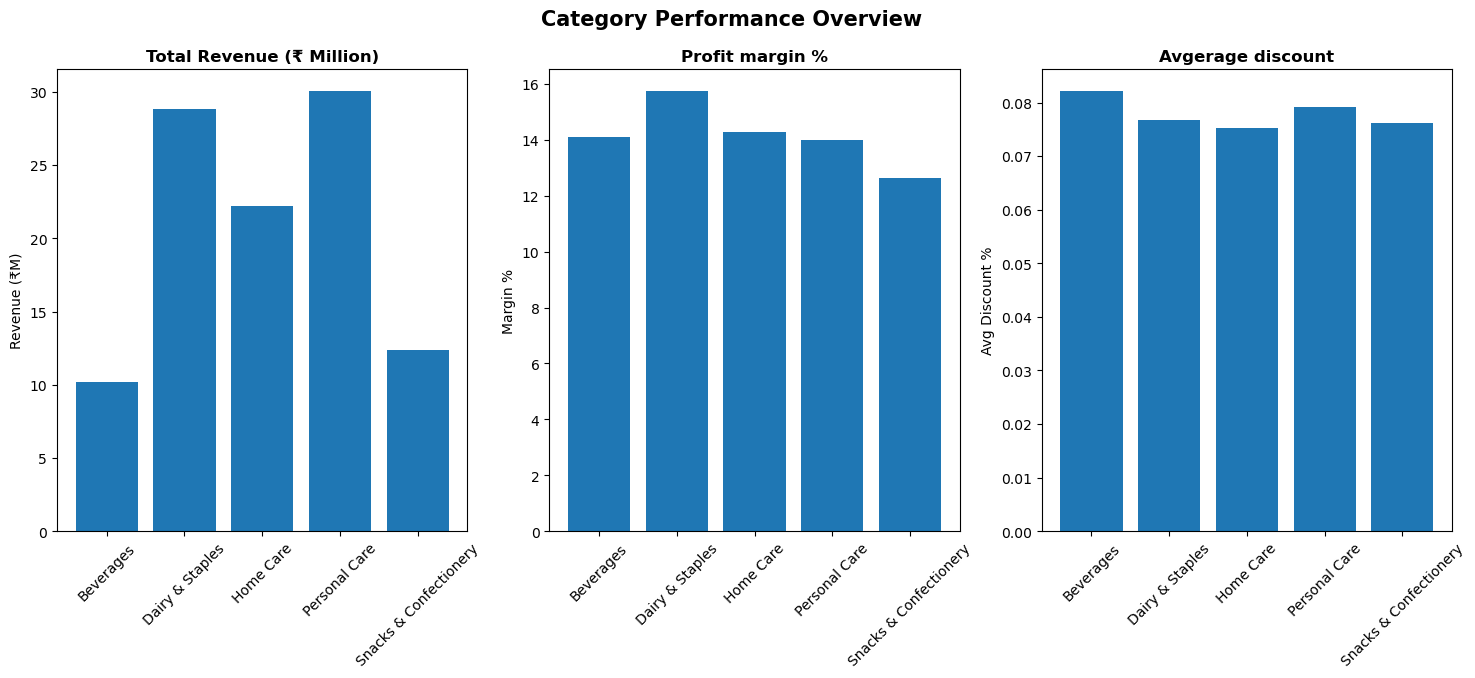

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Category Performance Overview', fontsize=15, fontweight='bold')

ax=axes[0]
rev_bar= ax.bar(cat_summary['Category'],cat_summary['Revenue_m'])
ax.set_title('Total Revenue (₹ Million)',fontweight='bold')
ax.set_ylabel('Revenue (₹M)')
ax.tick_params(axis='x', rotation=45)
ax=axes[1]
profit_bar= ax.bar(cat_summary['Category'],cat_summary['Profit_margin_%'])
ax.set_title('Profit margin %',fontweight='bold')
ax.set_ylabel('Margin %')
ax.tick_params(axis='x', rotation=45)
ax=axes[2]
avg_bar= ax.bar(cat_summary['Category'],cat_summary['Avg_discount'])
ax.set_title('Avgerage discount',fontweight='bold')
ax.set_ylabel('Avg Discount %')
ax.tick_params(axis='x', rotation=45)

In [31]:
cat_perf = df_sales.groupby('Category').agg(
Orders = ('Order_ID','nunique'),
Revenue = ('Sales_INR','sum'),
Total_profit = ('Profit_INR','sum'),
Returned = ('Returned', lambda x:(x == 'Yes').sum()),
).reset_index()

cat_perf['Profit_margin (%)'] = (
    cat_perf['Total_profit'] / cat_perf['Revenue'] * 100
).round(2)

cat_perf['Return_rate'] = (
    cat_perf['Returned'] / cat_perf['Orders'] * 100
).round(2)

display(cat_perf)

,Category,Orders,Revenue,Total_profit,Returned,Profit_margin (%),Return_rate
0,Beverages,3509,10219094.13,1439423.90,348,14.09,9.92
1,Dairy & Staples,3007,28850599.31,4540443.51,280,15.74,9.31
2,Home Care,3605,22218577.00,3175640.79,371,14.29,10.29
3,Personal Care,3558,30051554.72,4205584.83,365,13.99,10.26
4,Snacks & Confectionery,3236,12397323.68,1568624.73,290,12.65,8.96


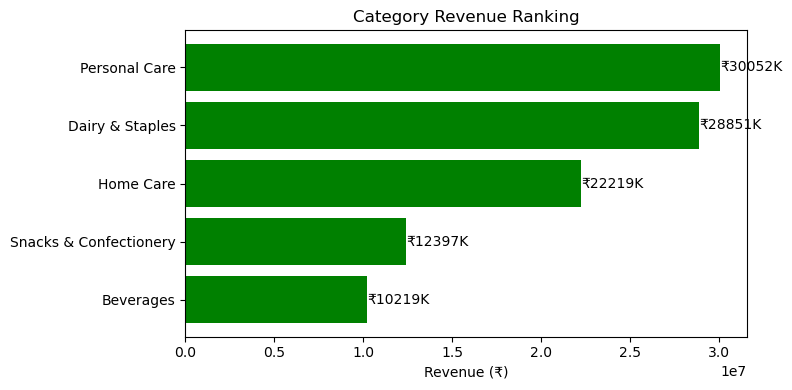

In [32]:
cat_plot = cat_perf.sort_values('Revenue')
COLORS = {
    'success': 'green',
    'danger': 'red'
}
profit_color= [
    COLORS['success'] if x >= 0 else COLORS['danger']
    for x in cat_plot['Total_profit']
]

fig, ax = plt.subplots(figsize=(8, 4))
bars=  ax.barh(
    cat_plot['Category'],
    cat_plot['Revenue'],
    color=profit_color
)
for bar, val in zip(bars, cat_plot['Revenue'] / 1000):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'₹{val:.0f}K',
        va='center'
    )
ax.set_xlabel('Revenue (₹)')
ax.set_title('Category Revenue Ranking')

plt.tight_layout()
plt.show()

In [33]:
disc_bucket = pd.cut(df_sales['Discount'],
                     bins = [-0.01,0.0,0.2,0.4,1.0],
                     labels = ['No Discount','0-20%','20-40%','>40%'])
disc_impact = df_sales.copy()
disc_impact['Discount_bucket'] = disc_bucket
disc_summary = disc_impact.groupby('Discount_bucket', observed = True).agg(
    Transactions = ('Order_ID','count'),
    Total_profit = ('Profit_INR','sum'),
    Total_revenue = ('Sales_INR','sum')
).reset_index()
disc_summary['Profit_margin'] = (disc_summary['Total_profit'] / disc_summary['Total_revenue'] * 100).round(1)

print("Discount Bucket Impact:")
display(disc_summary)
print(f"\n High discount(>40%) transactions:{(df_sales['Discount']>0.4).sum()}")
print(f"Revenue from high discount:₹{df_sales[df_sales['Discount']>0.4]['Sales_INR'].sum():,.0f}")
print(f"Profit from high discount:₹{df_sales[df_sales['Discount']>0.4]['Profit_INR'].sum():,.0f}")

Discount Bucket Impact:


,Discount_bucket,Transactions,Total_profit,Total_revenue,Profit_margin
0,No Discount,5800,8023697.12,39039946.09,20.6
1,0-20%,10321,7123775.62,60612180.08,11.8
2,20-40%,815,-221693.57,4055722.68,-5.5



 High discount(>40%) transactions:3
Revenue from high discount:₹29,300
Profit from high discount:₹3,939


In [34]:
ts = df_sales.copy()
ts['YearMonth'] = ts['Order_Date'].dt.to_period('M')

monthly_overall = ts.groupby('YearMonth')['Sales_INR'].sum().reset_index()
monthly_overall['YearMonth_dt'] = monthly_overall['YearMonth'].dt.to_timestamp()
monthly_overall = monthly_overall.sort_values('YearMonth_dt')
monthly_overall['MA3'] = monthly_overall['Sales_INR'].rolling(3).mean()

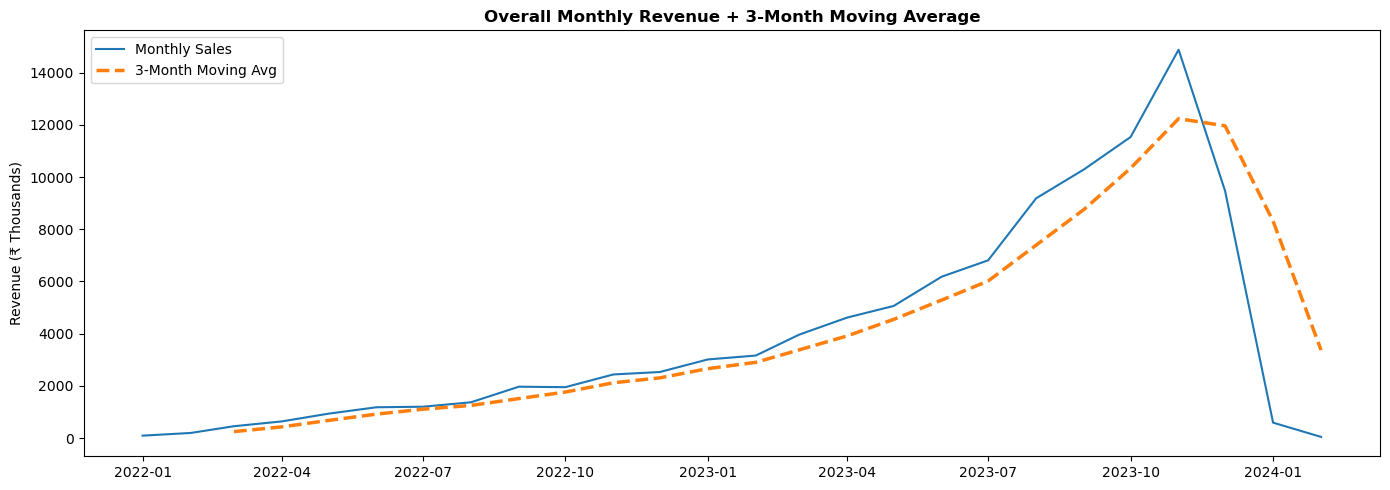

In [35]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_overall['YearMonth_dt'], monthly_overall['Sales_INR'] / 1000, linewidth=1.5, label='Monthly Sales')
ax.plot(monthly_overall['YearMonth_dt'], monthly_overall['MA3'] / 1000, linewidth=2.5, linestyle='--', label='3-Month Moving Avg')
ax.set_title('Overall Monthly Revenue + 3-Month Moving Average', fontweight='bold')
ax.set_ylabel('Revenue (₹ Thousands)')
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
monthly_cat = ts.groupby(['YearMonth', 'Category'])['Sales_INR'].sum().reset_index()
monthly_cat['YearMonth_dt'] = monthly_cat['YearMonth'].dt.to_timestamp()

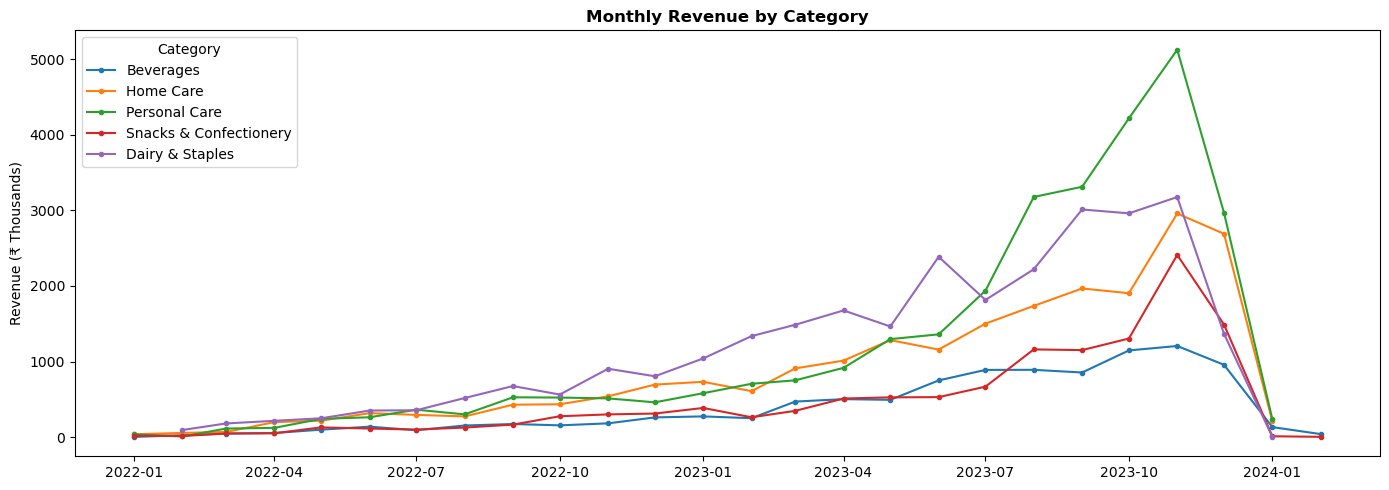

In [37]:
fig, ax = plt.subplots(figsize=(14, 5))
for cat in monthly_cat['Category'].unique():
    sub = monthly_cat[monthly_cat['Category'] == cat].sort_values('YearMonth_dt')
    ax.plot(sub['YearMonth_dt'], sub['Sales_INR'] / 1000, marker='o', markersize=3, linewidth=1.5, label=cat)
ax.set_title('Monthly Revenue by Category', fontweight='bold')
ax.set_ylabel('Revenue (₹ Thousands)')
ax.legend(title='Category')
plt.tight_layout()
plt.show()

In [38]:
yoy = ts.groupby(['Category', ts['Order_Date'].dt.year])['Sales_INR'].sum().unstack()
yoy_m = (yoy / 1e6).round(2)
print("Category Year-over-Year Revenue (₹ Millions):")
display(yoy_m)

Category Year-over-Year Revenue (₹ Millions):


Order_Date,2022,2023,2024
Category,,,
Beverages,1.37,8.68,0.17
Dairy & Staples,4.90,23.94,0.00
Home Care,3.55,18.46,0.21
Personal Care,3.46,26.35,0.24
Snacks & Confectionery,1.64,10.74,0.01


In [39]:
years = sorted(yoy.columns)
latest = years[-1]
previous = years[-2]

growth = ((yoy[latest] - yoy[previous]) / yoy[previous] * 100).round(1)
print(f"YoY Growth % ({previous} → {latest}):")
print(growth.to_string())

YoY Growth % (2023 → 2024):
Category
Beverages                 -98.0
Dairy & Staples          -100.0
Home Care                 -98.9
Personal Care             -99.1
Snacks & Confectionery    -99.9


In [40]:
status_counts = df_inv['Inventory_Status'].value_counts().reset_index()
status_counts.columns = ['Inventory_Status', 'Count']
display(status_counts)

,Inventory_Status,Count
0,Healthy,141
1,Slow Moving,112
2,Dead Stock,56
3,Out of Stock,4


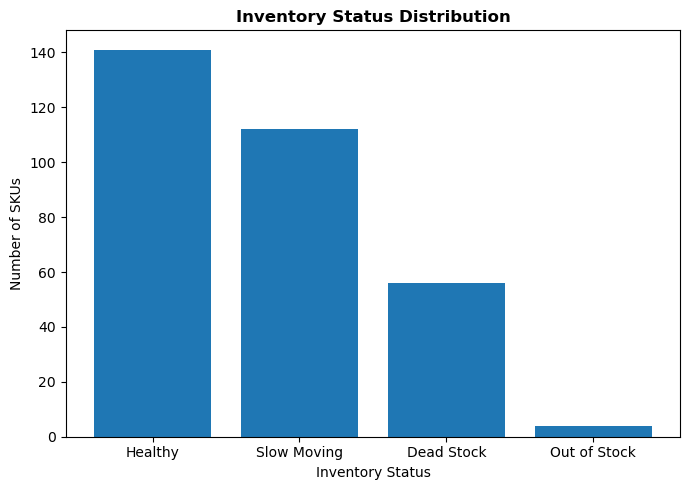

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(status_counts['Inventory_Status'], status_counts['Count'])
ax.set_title('Inventory Status Distribution', fontweight='bold')
ax.set_xlabel('Inventory Status')
ax.set_ylabel('Number of SKUs')
plt.tight_layout()
plt.show()

In [42]:
region_perf = df_sales.groupby('Region').agg(
    Orders=('Order_ID', 'nunique'),
    Revenue=('Sales_INR', 'sum'),
    Profit=('Profit_INR', 'sum')
).reset_index()

region_perf['Profit_margin_%'] = (region_perf['Profit'] / region_perf['Revenue'] * 100).round(2)
display(region_perf)

,Region,Orders,Revenue,Profit,Profit_margin_%
0,Central,3440,22544140.22,3374325.42,14.97
1,East,3311,21028835.02,3216271.77,15.29
2,North,2708,16103844.00,2250352.99,13.97
3,South,2628,16199052.95,2248559.82,13.88
4,West,4828,27861276.65,3840207.76,13.78


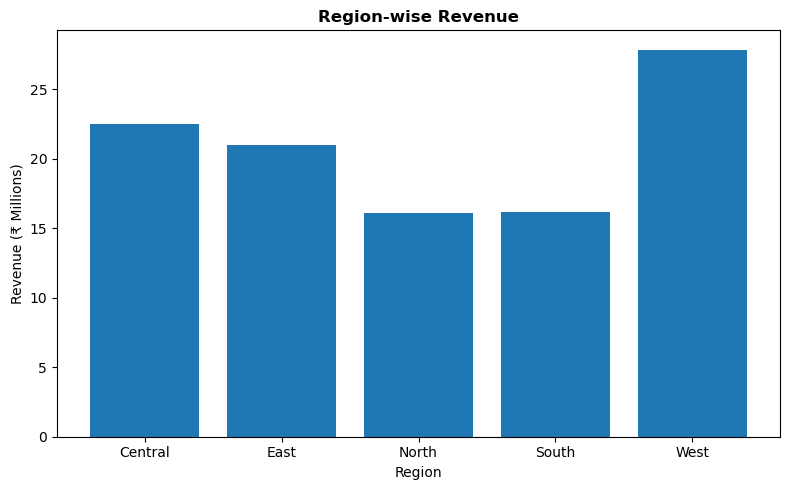

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(region_perf['Region'], region_perf['Revenue'] / 1e6)
ax.set_title('Region-wise Revenue', fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Revenue (₹ Millions)')
plt.tight_layout()
plt.show()

In [44]:
top10 = df_inv.nlargest(10, 'Total_Revenue_INR')[['SKU_ID', 'Product_Name', 'Category', 'Total_Revenue_INR']]
print("Top 10 SKUs by Revenue:")
display(top10)

Top 10 SKUs by Revenue:


,SKU_ID,Product_Name,Category,Total_Revenue_INR
301,FMCG_DAI_0302,Nestle Ghee & Oil 250g,Dairy & Staples,1680565.45
172,FMCG_PER_0173,Head & Shoulders Shampoo 5kg,Personal Care,1637961.48
174,FMCG_PER_0175,Himalaya Soap 100ml,Personal Care,1614704.57
141,FMCG_PER_0142,Lux Face Wash 500g,Personal Care,1520814.09
252,FMCG_HOM_0253,Rin Floor Cleaner 1L,Home Care,1374796.35
229,FMCG_HOM_0230,Nirma Detergent 100ml,Home Care,1355487.13
310,FMCG_DAI_0311,Uttam Pulses 750ml,Dairy & Staples,1323320.43
193,FMCG_PER_0194,Axe Soap 500g,Personal Care,1294487.20
179,FMCG_PER_0180,Dettol Toothpaste 50g,Personal Care,1242210.99
160,FMCG_PER_0161,Colgate Deodorant 500g,Personal Care,1203883.48


In [45]:
bottom10 = df_inv.nsmallest(10, 'Total_Revenue_INR')[['SKU_ID', 'Product_Name', 'Category', 'Total_Revenue_INR']]
print("Bottom 10 SKUs by Revenue:")
display(bottom10)

Bottom 10 SKUs by Revenue:


,SKU_ID,Product_Name,Category,Total_Revenue_INR
251,FMCG_HOM_0252,Ariel Air Freshener 250g,Home Care,349.54
9,FMCG_BEV_0010,Bru Juices 750ml,Beverages,1255.79
51,FMCG_BEV_0052,Sprite Energy Drinks 200ml,Beverages,1303.92
44,FMCG_BEV_0045,Kinley Juices 750ml,Beverages,1466.67
124,FMCG_SNA_0125,Good Day Candies 750ml,Snacks & Confectionery,3206.74
245,FMCG_HOM_0246,Odonil Toilet Cleaner 1L,Home Care,4496.19
333,FMCG_DAI_0334,Patanjali Atta & Rice 5kg,Dairy & Staples,4669.56
54,FMCG_BEV_0055,Thums Up Soft Drinks 250g,Beverages,6663.47
273,FMCG_HOM_0274,Tide Detergent 500g,Home Care,6923.61
291,FMCG_DAI_0292,Fortune Atta & Rice 50g,Dairy & Staples,7155.83


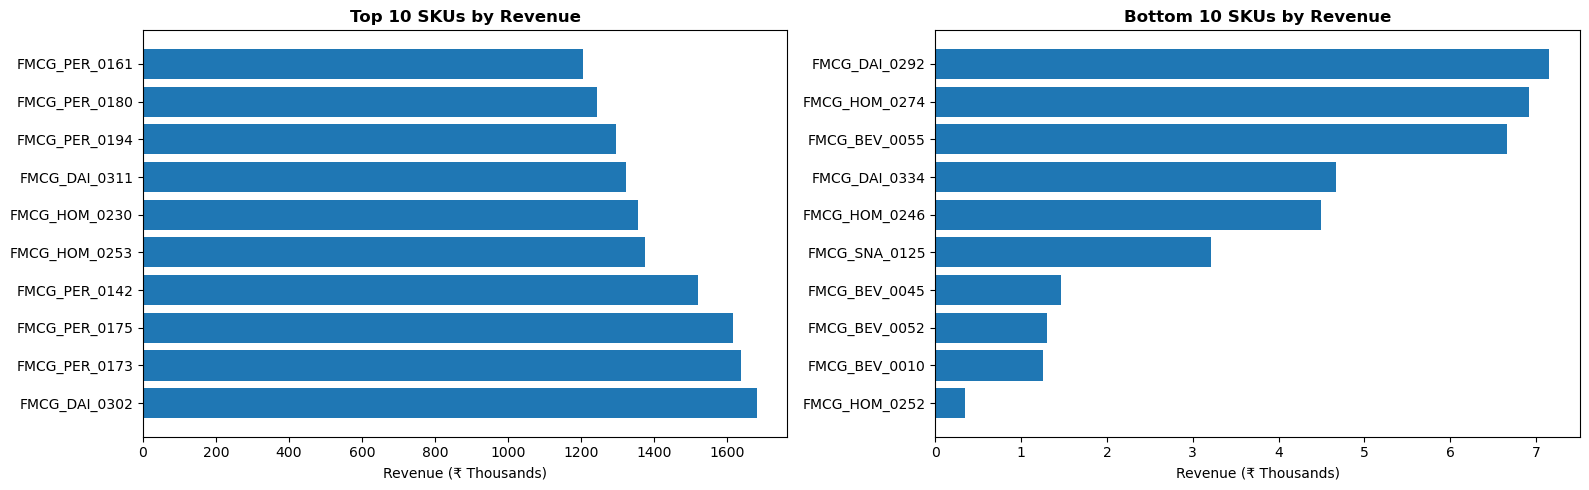

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.barh(top10['SKU_ID'], top10['Total_Revenue_INR'] / 1000)
ax.set_title('Top 10 SKUs by Revenue', fontweight='bold')
ax.set_xlabel('Revenue (₹ Thousands)')

ax = axes[1]
ax.barh(bottom10['SKU_ID'], bottom10['Total_Revenue_INR'] / 1000)
ax.set_title('Bottom 10 SKUs by Revenue', fontweight='bold')
ax.set_xlabel('Revenue (₹ Thousands)')

plt.tight_layout()
plt.show()

In [47]:
return_analysis = df_sales.groupby('Category').agg(
    Total_Orders=('Order_ID', 'count'),
    Returned=('Returned', lambda x: (x == 'Yes').sum())
).reset_index()

return_analysis['Return_Rate_%'] = (return_analysis['Returned'] / return_analysis['Total_Orders'] * 100).round(2)
display(return_analysis)

,Category,Total_Orders,Returned,Return_Rate_%
0,Beverages,3512,348,9.91
1,Dairy & Staples,3013,280,9.29
2,Home Care,3615,371,10.26
3,Personal Care,3560,365,10.25
4,Snacks & Confectionery,3239,290,8.95


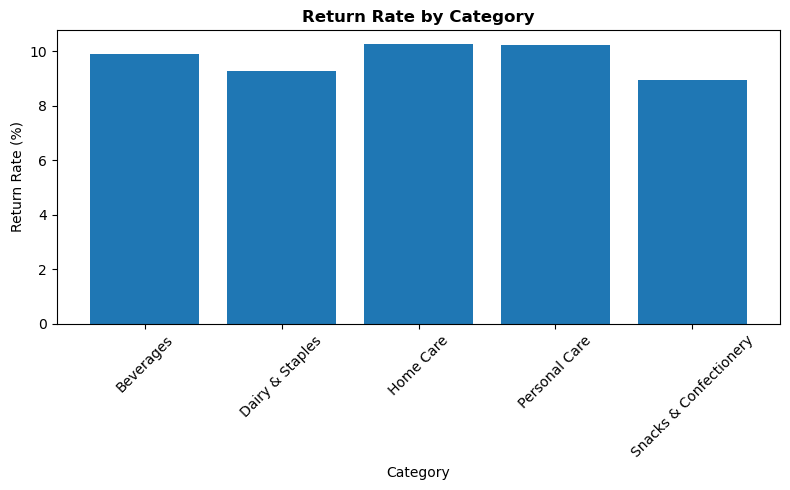

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(return_analysis['Category'], return_analysis['Return_Rate_%'])
ax.set_title('Return Rate by Category', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Return Rate (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [49]:
df_model = df_inv[['SKU_ID', 'Days_Since_Last_Sale', 'Current_Stock_Qty', 'Reorder_Point',
                    'Lead_Time_Days', 'Total_Qty_Sold', 'Total_Revenue_INR', 'Total_Profit_INR',
                    'Avg_Unit_Sell_INR', 'Avg_Unit_Cost_INR', 'Return_Count', 'Days_To_Expiry',
                    'Inventory_Status']].copy()

print(df_model.shape)
print(df_model.head())

(313, 13)
          SKU_ID  Days_Since_Last_Sale  Current_Stock_Qty  Reorder_Point  \
0  FMCG_BEV_0001                     6                106             42   
1  FMCG_BEV_0002                    34                 82            127   
2  FMCG_BEV_0003                    41                 13             46   
3  FMCG_BEV_0004                    44                 62            116   
4  FMCG_BEV_0005                    15                  3             40   

   Lead_Time_Days  Total_Qty_Sold  Total_Revenue_INR  Total_Profit_INR  \
0            21.0            2796          419035.17          27762.93   
1            10.0            3033          319908.08           6508.19   
2             5.0             843           82189.95           5890.02   
3             5.0            1084          199843.58          37135.18   
4            10.0            1621          222662.88           5108.47   

   Avg_Unit_Sell_INR  Avg_Unit_Cost_INR  Return_Count  Days_To_Expiry  \
0             1

In [50]:
# relabeling inventory status using multiple business rules
# original labels were based only on days since last sale
# adding qty sold, return count and revenue as conditions for better separation

def assign_status(row):
    if row['Current_Stock_Qty'] == 0:
        return 'Out of Stock'
    elif (row['Days_Since_Last_Sale'] > 90 and row['Total_Qty_Sold'] < 381):
        return 'Dead Stock'
    elif (row['Days_Since_Last_Sale'] > 90 and row['Return_Count'] > 8):
        return 'Dead Stock'
    elif (row['Days_Since_Last_Sale'] > 32 and row['Total_Qty_Sold'] < 1077):
        return 'Slow Moving'
    elif (row['Days_Since_Last_Sale'] > 32 and row['Return_Count'] > 7):
        return 'Slow Moving'
    elif (row['Total_Revenue_INR'] < 64392 and row['Days_Since_Last_Sale'] > 17):
        return 'Slow Moving'
    else:
        return 'Healthy'

df_model['Inventory_Status'] = df_model.apply(assign_status, axis=1)
print(df_model['Inventory_Status'].value_counts())

Inventory_Status
Healthy         169
Slow Moving      97
Dead Stock       43
Out of Stock      4
Name: count, dtype: int64


In [51]:
# derived features
df_model['Stock_to_Reorder_ratio'] = df_model['Current_Stock_Qty'] / (df_model['Reorder_Point'] + 1)
df_model['Revenue_per_day'] = df_model['Total_Revenue_INR'] / (df_model['Days_Since_Last_Sale'] + 1)
df_model['Profit_margin'] = df_model['Total_Profit_INR'] / (df_model['Total_Revenue_INR'] + 1)
df_model['Sell_through_rate'] = df_model['Total_Qty_Sold'] / (df_model['Total_Qty_Sold'] + df_model['Current_Stock_Qty'] + 1)

print(df_model.shape)
print(df_model.head())

(313, 17)
          SKU_ID  Days_Since_Last_Sale  Current_Stock_Qty  Reorder_Point  \
0  FMCG_BEV_0001                     6                106             42   
1  FMCG_BEV_0002                    34                 82            127   
2  FMCG_BEV_0003                    41                 13             46   
3  FMCG_BEV_0004                    44                 62            116   
4  FMCG_BEV_0005                    15                  3             40   

   Lead_Time_Days  Total_Qty_Sold  Total_Revenue_INR  Total_Profit_INR  \
0            21.0            2796          419035.17          27762.93   
1            10.0            3033          319908.08           6508.19   
2             5.0             843           82189.95           5890.02   
3             5.0            1084          199843.58          37135.18   
4            10.0            1621          222662.88           5108.47   

   Avg_Unit_Sell_INR  Avg_Unit_Cost_INR  Return_Count  Days_To_Expiry  \
0             1

In [52]:
print(df_model.isnull().sum())
df_model = df_model.dropna()
df_model = df_model[df_model['Inventory_Status'] != 'Out of Stock']
print(df_model.shape)

SKU_ID                    0
Days_Since_Last_Sale      0
Current_Stock_Qty         0
Reorder_Point             0
Lead_Time_Days            0
Total_Qty_Sold            0
Total_Revenue_INR         0
Total_Profit_INR          0
Avg_Unit_Sell_INR         0
Avg_Unit_Cost_INR         0
Return_Count              0
Days_To_Expiry            0
Inventory_Status          0
Stock_to_Reorder_ratio    0
Revenue_per_day           0
Profit_margin             0
Sell_through_rate         0
dtype: int64
(309, 17)


In [53]:
status_map = {'Healthy': 0, 'Slow Moving': 1, 'Dead Stock': 2}
df_model['Status_Code'] = df_model['Inventory_Status'].map(status_map)
print(df_model['Status_Code'].value_counts())

Status_Code
0    169
1     97
2     43
Name: count, dtype: int64


In [54]:
X = df_model.drop(columns=['SKU_ID', 'Inventory_Status', 'Status_Code'])
y = df_model['Status_Code']

print(X.shape)
print(y.value_counts())

(309, 15)
Status_Code
0    169
1     97
2     43
Name: count, dtype: int64


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (247, 15), Test: (62, 15)


## 6. Model Training

In [56]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

models = {
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='mlogloss'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}
for name, m in models.items():
    if name == 'XGBoost':
        m.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        m.fit(X_train, y_train)
    pred = m.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

XGBoost: 0.9677
Random Forest: 0.9355
Decision Tree: 0.9677
KNN: 0.5968


In [57]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"Best Model: {best_model_name} with accuracy {results[best_model_name]:.4f}")

Best Model: XGBoost with accuracy 0.9677


Classification Report - XGBoost
              precision    recall  f1-score   support

     Healthy       0.94      1.00      0.97        34
 Slow Moving       1.00      0.89      0.94        19
  Dead Stock       1.00      1.00      1.00         9

    accuracy                           0.97        62
   macro avg       0.98      0.96      0.97        62
weighted avg       0.97      0.97      0.97        62



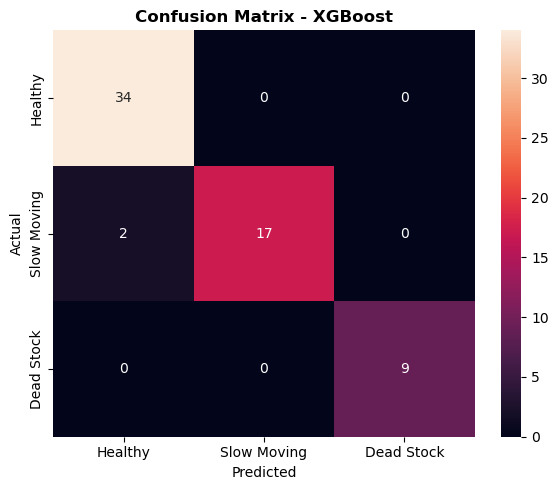

In [58]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print(f"Classification Report - {best_model_name}")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Slow Moving', 'Dead Stock']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Healthy', 'Slow Moving', 'Dead Stock'], yticklabels=['Healthy', 'Slow Moving', 'Dead Stock'])
ax.set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

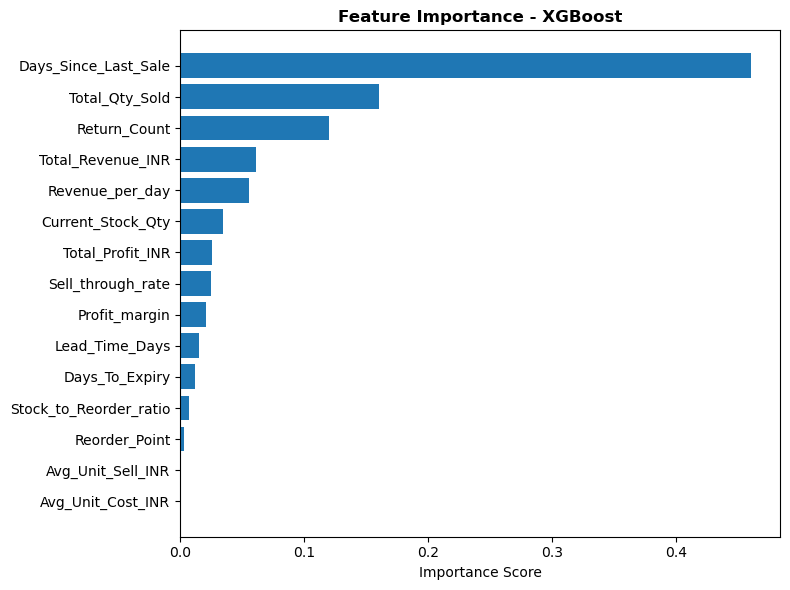

In [59]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_imp.index, feat_imp.values)
ax.set_title(f'Feature Importance - {best_model_name}', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [60]:
import joblib
joblib.dump(best_model, 'inventory_model.pkl')
joblib.dump(list(X.columns), 'model_features.pkl')
print("Model saved.")

Model saved.
